In [1]:
pip install imbalanced-learn
pip install xgboost
pip install shap

SyntaxError: invalid syntax (1837285608.py, line 1)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
import shap
from scipy import stats
import warnings
from pathlib import Path
import pickle
from datetime import datetime
import pytz
import random
import os
warnings.filterwarnings('ignore')



c:\Users\skgmo\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Clone from GitHub Repository

In [ ]:
# Clone git repo on Google Colab
!git clone https://github.com/DayDayUp-STERN/ddu_data_and_processing_scripts.git

Cloning into 'ddu_data_and_processing_scripts'...
remote: Enumerating objects: 16054, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 16054 (delta 0), reused 0 (delta 0), pack-reused 16050 (from 1)
Receiving objects: 100% (16054/16054), 560.23 MiB | 15.91 MiB/s, done.
Resolving deltas: 100% (1711/1711), done.
Updating files: 100% (16473/16473), done.


In [2]:
from pathlib import Path
print(f"Current working directory: {Path.cwd()}")


Current working directory: c:\Users\skgmo\Downloads


In [2]:
## For gc bucket
import os
os.chdir("c:/Users/skgmo")
#os.chdir("ddu_data_and_processing_scripts")
print(f"Changed working directory to: {Path.cwd()}")


Changed working directory to: c:\Users\skgmo


In [3]:
## For Local
import os
os.chdir("C:/Users/skgmo/ddu_data_and_processing_scripts")
print(f"Changed working directory to: {Path.cwd()}")

Changed working directory to: C:\Users\skgmo\ddu_data_and_processing_scripts


for test path
-/content/ddu_data_and_processing_scripts/data/raw_data/B0057LAHZK_raw.pkl

# 1 Converting Keepa time to EST datetime

In [4]:
def keepa_to_est(keepa_time):
    """Convert Keepa time to EST datetime"""
    if isinstance(keepa_time, datetime):
        if keepa_time.tzinfo is None:
            keepa_time = pytz.UTC.localize(keepa_time)
        return keepa_time.astimezone(pytz.timezone('US/Eastern'))

    try:
        unix_time = (keepa_time + 21564000) * 60
        utc_time = datetime.fromtimestamp(unix_time, tz=pytz.UTC)
        return utc_time.astimezone(pytz.timezone('US/Eastern'))
    except TypeError as e:
        print(f"Error converting time: {keepa_time}, type: {type(keepa_time)}")
        raise e

def check_data_completeness(df, required_metrics):
    """
    Check if the data contains all required metrics
    Return (is_complete, missing_metrics)
    """
    existing_columns = set(df.columns)
    required_metrics = set(required_metrics)
    missing_metrics = required_metrics - existing_columns

    # Check if all required columns exist
    if missing_metrics:
        return False, missing_metrics

    # # Check if each column has enough non-null values (e.g., at least 80% of the data)
    # threshold = 0.8
    # for metric in required_metrics:
    #     if df[metric].isna().mean() > (1 - threshold):
    #         missing_metrics.add(f"{metric} (>80% missing)")
    #         return False, missing_metrics

    return True, set()


# 1-2 Product data: Filter Last 3 years
- Get timeseries data and categorical data from AMAZON keepa JSON file

In [5]:
from datetime import datetime, timedelta
import pytz

def process_data_to_timeseries(file_path):
    """Convert nested data structure to time series DataFrame"""
    required_metrics = {
        'SALES', 'LISTPRICE', 'BUY_BOX_SHIPPING',
        'COUNT_REVIEWS', 'RATING','COUNT_NEW'
    }
    # required_metrics = {
    #     'SALES', 'LISTPRICE', 'BUY_BOX_SHIPPING',
    #     'COUNT_REVIEWS', 'RATING'
    # }

    try:
        with open(file_path, 'rb') as f:
            data = pickle.load(f)

        nested_data = data.get('data', {})
        asin = data.get('asin', 'unknown')

        # Sub Category
        categoryTree = data.get('categoryTree', 'unknown')
        last_category_name = categoryTree[-1].get('name', None) if categoryTree else None

        # ItemTypeKeyword
        TypeKeyword = data.get('itemTypeKeyword','unknown')
        if TypeKeyword:
          TypeKeyword = data.get('itemTypeKeyword',None)
        else:
          TypeKeyword = None

        # isSNS
        isSNS = data.get('isSNS','False')
        if isSNS:
          isSNS = data.get('isSNS','False')
        else:
          isSNS = 'False'

        metrics = {
            'AMAZON': ['AMAZON_time', 'AMAZON'],
            'NEW': ['NEW_time', 'NEW'],
            'USED': ['USED_time', 'USED'],
            'SALES': ['SALES_time', 'SALES'],
            'LISTPRICE': ['LISTPRICE_time', 'LISTPRICE'],
            'NEW_FBA': ['NEW_FBA_time', 'NEW_FBA'],
            'COUNT_NEW': ['COUNT_NEW_time', 'COUNT_NEW'],
            'RATING': ['RATING_time', 'RATING'],
            'COUNT_REVIEWS': ['COUNT_REVIEWS_time', 'COUNT_REVIEWS'],
            'BUY_BOX_SHIPPING': ['BUY_BOX_SHIPPING_time', 'BUY_BOX_SHIPPING']
        }

        time_series_dict = {}
        for metric_name, (time_key, value_key) in metrics.items():
            if time_key in nested_data and value_key in nested_data:
                times = nested_data[time_key]
                values = nested_data[value_key]

                if not isinstance(times, (list, np.ndarray)) or not isinstance(values, (list, np.ndarray)):
                    continue

                for t, v in zip(times, values):
                    try:
                        est_time = keepa_to_est(t)
                        if est_time not in time_series_dict:
                            time_series_dict[est_time] = {}
                        time_series_dict[est_time][metric_name] = np.nan if v == -1 else v
                    except Exception as e:
                        print(f"Error processing {metric_name} for {asin}: {str(e)}")
                        continue

        if not time_series_dict:
            print(f"No valid data found for {asin}")
            return None, asin

        df = pd.DataFrame.from_dict(time_series_dict, orient='index')
        df.sort_index(inplace=True)


        ### 📌 **Compress timestamp into a day**
        df.index = pd.to_datetime(df.index).floor('D')
        df = df.groupby(df.index).max()
        #Check
        # print(f"time_series_dict {df.head(20)}")

###///　Added
        ### 📌 **Fix timezone issue for filtering last 3 years**
        three_years_ago = datetime.now(pytz.UTC) - timedelta(days=3*365)  # 3年前のUTC時間
        three_years_ago = three_years_ago.astimezone(pytz.timezone("US/Eastern"))  # US/Easternに変換
        df = df[df.index >= three_years_ago]  # 3年前より新しいデータのみ保持
        # Check
        # print(f"4years {df.head(20)}")
        # print(f"LISTPRICE {df['LISTPRICE']}")
###///

        ### 📌 **Check data completeness**
        is_complete, missing_metrics = check_data_completeness(df, required_metrics)

####/// Added Skip if all values of LISTPRICE is NaN
        # # `required_metrics` のカラムの中で、すべてのレコードが NaN のものが 1つでもある場合
        # if df[required_metrics].isna().all().any():
        #     print(f"Skipping {asin} because at least one required metric is completely NaN.")
        #     return None, asin

        # すべてのレコードがNaNの `required_metrics` が ある場合スキップ
        if df['LISTPRICE'].isna().all(axis=0).all():
            print(f"Skipping {asin} because all required metrics are NaN.")
            return None, asin
####///

        if not is_complete:
            print(f"Incomplete data for {asin}. Missing metrics: {missing_metrics}")
            return None, asin

        # **Basic data check**
        if len(df) < 60:  # Ensure at least 60 days of data
            print(f"Insufficient data points for {asin}: {len(df)} < 60 days")
            return None, asin

        # NaN の数を表示
        missing_counts = df['LISTPRICE'].isna().sum()
        print(f"NaN counts for {asin}:\n{missing_counts}")

        df = df.ffill().bfill()
        df.fillna(0, inplace=True)  # ListPrice is likely to be all 0 in 3 years
        df['ASIN'] = asin

        #Check
        #print(f"ffill bfill {df}")

        ## **Categorical Variables**
        df['SubCategory'] = last_category_name
        df['TypeKeyword'] = TypeKeyword
        df['TypeKeyword'] = df['TypeKeyword'].astype(str).str.split('-').str[-1]
        df['isSNS'] = isSNS

        #print("最古の日付:", df.index.min())
        #print("最新の日付:", df.index.max())
        print("Record:", df.shape[0])


        return df, asin

    except Exception as e:
        print(f"Error processing file {file_path}: {str(e)}")
        return None, None


In [14]:
# Test
test = process_data_to_timeseries("C:/Users/skgmo/ddu_data_and_processing_scripts/data/raw_data/B07M5M47FM_raw.pkl")
print(test)
print(test[0].dtypes)

NaN counts for B07M5M47FM:
1023
Record: 1034
(                           AMAZON   NEW  USED  SALES  LISTPRICE  COUNT_NEW  \
2022-03-16 00:00:00-04:00    4.49  4.48   0.0   69.0       4.49        4.0   
2022-03-17 00:00:00-04:00    4.49  4.48   0.0   65.0       4.49        4.0   
2022-03-18 00:00:00-04:00    4.49  4.48   0.0   69.0       4.49        4.0   
2022-03-19 00:00:00-04:00    4.49  4.48   0.0   74.0       4.49        4.0   
2022-03-20 00:00:00-04:00    4.49  4.48   0.0   74.0       4.49        4.0   
...                           ...   ...   ...    ...        ...        ...   
2025-01-08 00:00:00-05:00    6.12  6.12   0.0   23.0       6.99        5.0   
2025-01-09 00:00:00-05:00    6.12  6.12   0.0   24.0       6.99        5.0   
2025-01-10 00:00:00-05:00    6.12  6.12   0.0   24.0       6.99        5.0   
2025-01-11 00:00:00-05:00    6.12  6.12   0.0   22.0       6.99        5.0   
2025-01-12 00:00:00-05:00    6.12  6.12   0.0   21.0       6.99        5.0   

                 

# 1-3 Generate features
- Timeseries
- Week / Month factors
- External (Temperature)

In [6]:
def preprocess_data(df):
    """Apply all preprocessing steps"""
    # Replace inf and -inf with 0
    df = df.replace([np.inf, -np.inf], 0)

    # Calculate rolling averages
    df['Sales_rank_rolling_7'] = df['SALES'].rolling(window=7, min_periods=1).mean()
    df['Sales_rank_rolling_30'] = df['SALES'].rolling(window=30, min_periods=1).mean()
    df['Sales_rank_rolling_60'] = df['SALES'].rolling(window=60, min_periods=1).mean()
    df['Sales_rank_rolling_90'] = df['SALES'].rolling(window=90, min_periods=1).mean()

    df['List_price_rolling_7'] = df['LISTPRICE'].rolling(window=7, min_periods=1).mean()
    df['List_price_rolling_30'] = df['LISTPRICE'].rolling(window=30, min_periods=1).mean()
    df['Buy_box_price_rolling_7'] = df['BUY_BOX_SHIPPING'].rolling(window=7, min_periods=1).mean()
    df['Buy_box_price_rolling_30'] = df['BUY_BOX_SHIPPING'].rolling(window=30, min_periods=1).mean()

    # Calculate price changes (use clip to avoid -inf)
    df['List_price_change_7'] = df['LISTPRICE'].pct_change(periods=7).clip(-1, 1) * 100
    df['Buy_box_price_change_7'] = df['BUY_BOX_SHIPPING'].pct_change(periods=7).clip(-1, 1) * 100

    # Calculate review metrics
    df['New_reviews'] = df['COUNT_REVIEWS'].diff(periods=7).fillna(0)
    df['Review_growth_rate'] = df['COUNT_REVIEWS'].pct_change().clip(-1, 1) * 100

    # Calculate future metrics
    future_sales_rank = df['SALES'].shift(-30)
    current_sales_rank = df['SALES']
    df['Sales_rank_change_30d'] = ((future_sales_rank - current_sales_rank) / current_sales_rank).clip(-1, 1) * 100
    df['Sales_rank_change_30d'] = df['Sales_rank_change_30d'].fillna(0) # Ensure no NaN values

    # Calculate Go_viral
    df['Go_viral'] = (df['Sales_rank_change_30d'] < -30).astype(int)

    # Check the ratio of Go_viral
    viral_ratio = df['Go_viral'].mean()
    print(f"\nViral ratio for ASIN {df['ASIN'].iloc[0]}: {viral_ratio:.2%}")


    # Save the value of Go_viral
    go_viral_values = df['Go_viral'].copy()

    # If the viral ratio is less than 5%, return None
    if viral_ratio < 0.05:
        print(f"Insufficient viral ratio ({viral_ratio:.2%} < 5%) for ASIN {df['ASIN'].iloc[0]}")
        return None

    # Handle missing values and outliers
    for col in df.columns:
        if col in ['Go_viral', 'ASIN']:
            continue
        if df[col].dtype in ['float64', 'int64']:
            if col.endswith(('_7', '_30', '_60', '_90', '_change_7', '_change_30d')):
                df[col] = df[col].ffill().bfill()
            else:
                q1 = df[col].quantile(0.25)
                q3 = df[col].quantile(0.75)
                iqr = q3 - q1
                lower_bound = q1 - 1.5 * iqr
                upper_bound = q3 + 1.5 * iqr
                df[col] = df[col].clip(lower_bound, upper_bound)
                df[col] = df[col].fillna(df[col].median())

    # Rename columns for consistency
    df = df.rename(columns={
        'SALES': 'Sales_rank',
        'LISTPRICE': 'List_price',
        'BUY_BOX_SHIPPING': 'Buy_box_price',
        'COUNT_REVIEWS': 'Review_count',
        'RATING': 'Rating'
    })

    # Restore the original value of Go_viral
    df['Go_viral'] = go_viral_values

    # === 🆕 Add Week Category ===
    df['week_of_month'] = ((df.index.day - 1) // 7 + 1).astype(int)  # 1週目〜5週目
    df['week_of_month'] = df['week_of_month'].clip(upper=4)  # 5週目を4週目に統合

    # === 🆕 Add Month Category ===
    df['month'] = df.index.month  # 1月〜12月を取得
    #print(f"month type {type(df['month'][0])}")

    # 月ごとの温度データを辞書として定義
    month_temperature = {
    1: 11.2, 2: 12.3, 3: 16.0, 4: 20.4, 5: 24.3, 6: 26.9,
    7: 29.5, 8: 29.1, 9: 26.8, 10: 22.5, 11: 17.0, 12: 12.3}

# df に temperature カラムを追加
    df['temperature'] = df['month'].map(month_temperature)

    # Print column names
    print(df.columns)

    return df


In [31]:
# Test: preprocess_data
test_preprocess_data = preprocess_data(test[0])
print(test_preprocess_data.head(3))


Viral ratio for ASIN B07M5M47FM: 22.73%
Index(['AMAZON', 'NEW', 'USED', 'Sales_rank', 'List_price', 'COUNT_NEW',
       'Review_count', 'Buy_box_price', 'NEW_FBA', 'Rating', 'ASIN',
       'SubCategory', 'TypeKeyword', 'isSNS', 'Sales_rank_rolling_7',
       'Sales_rank_rolling_30', 'Sales_rank_rolling_60',
       'Sales_rank_rolling_90', 'List_price_rolling_7',
       'List_price_rolling_30', 'Buy_box_price_rolling_7',
       'Buy_box_price_rolling_30', 'List_price_change_7',
       'Buy_box_price_change_7', 'New_reviews', 'Review_growth_rate',
       'Sales_rank_change_30d', 'Go_viral', 'week_of_month', 'month',
       'temperature'],
      dtype='object')
                           AMAZON   NEW  USED  Sales_rank  List_price  \
2022-03-16 00:00:00-04:00    4.49  4.49   0.0        69.0        6.99   
2022-03-17 00:00:00-04:00    4.49  4.49   0.0        65.0        6.99   
2022-03-18 00:00:00-04:00    4.49  4.49   0.0        69.0        6.99   

                           COUNT_NEW  R

# 2 get_project_path

In [7]:
def get_project_paths():
    """Get all project-related paths"""
    # Use the current working directory in Jupyter Notebook
    current_dir = Path.cwd()

    # If the current directory is 'src', then the parent directory is the project root
    if current_dir.name == 'src':
       # project_root = current_dir.parent
        project_root = Path.cwd() / "ddu_data_and_processing_scripts"
    else:
        # Otherwise, assume the current directory is the project root
        project_root = current_dir

     # Construct all necessary paths
    paths = {
        'root': project_root,
        'raw_data': project_root / 'data' / 'raw_data',
        'processed_data': project_root / 'data' / 'processed_data',
        'results': project_root / 'results'
    }

    # Ensure that the required directories exist
    paths['processed_data'].mkdir(parents=True, exist_ok=True)
    paths['results'].mkdir(parents=True, exist_ok=True)

    # Verify that the raw_data directory exists
    if not paths['raw_data'].exists():
        raise FileNotFoundError(f"Raw data directory not found at {paths['raw_data']}")

    # Print the current path information (for debugging)
    print(f"Current directory: {current_dir}")
    print(f"Project root: {project_root}")
    print(f"Raw data path: {paths['raw_data']}")

    return paths



In [ ]:
get_project_paths()

Current directory: /content/ddu_data_and_processing_scripts
Project root: /content/ddu_data_and_processing_scripts
Raw data path: /content/ddu_data_and_processing_scripts/data/raw_data


{'root': PosixPath('/content/ddu_data_and_processing_scripts'),
 'raw_data': PosixPath('/content/ddu_data_and_processing_scripts/data/raw_data'),
 'processed_data': PosixPath('/content/ddu_data_and_processing_scripts/data/processed_data'),
 'results': PosixPath('/content/ddu_data_and_processing_scripts/results')}

# 3 Load data and generate "final_df"

In [10]:
# グローバル変数として final_df を定義
final_df = None

def process_final_df():
    """Process raw data files and create global final_df (Only processing, no analysis)"""
    global final_df  # グローバル変数として設定
    try:
        paths = get_project_paths()
    except FileNotFoundError as e:
        print(f"Error: {e}")
        return None, None

    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    pkl_files = list(paths['raw_data'].glob('*_raw.pkl'))

    if not pkl_files:
        print(f"No pkl files found in {paths['raw_data']}")
        return None, None

    print(f"Found {len(pkl_files)} pkl files in {paths['raw_data']}")

    successful_files = []
    valid_dfs = []
    processed_asins = set()
    max_attempts = len(pkl_files)
    attempts = 0

    while len(valid_dfs) <= 500 and attempts < max_attempts:
        remaining_files = [f for f in pkl_files if f.stem.split('_')[0] not in processed_asins]
        if not remaining_files:
            break

        file_path = random.choice(remaining_files)
        asin = file_path.stem.split('_')[0]
        processed_asins.add(asin)

        print(f"\nProcessing {file_path.name}...")
        try:
            df, current_asin = process_data_to_timeseries(file_path)
            if df is not None:
                df = preprocess_data(df)
                if df is not None:
                    valid_dfs.append(df)
                    successful_files.append(file_path)
                    print(f"Successfully processed {current_asin}, viral ratio: {df['Go_viral'].mean():.2%}")
                else:
                    print(f"Skipped {asin} due to insufficient viral ratio")
            else:
                print(f"Skipped {asin} due to invalid or incomplete data")
        except Exception as e:
            print(f"Error processing {asin}: {str(e)}")

        attempts += 1
        print(f"Progress: {len(valid_dfs)}/500 valid files found ({attempts}/{max_attempts} attempts)")

    if not valid_dfs:
        print("No valid data files found after processing")
        return None, None

    # 🎯 ここで final_df を作成するだけ！ (分析はしない)
    final_df = pd.concat(valid_dfs, ignore_index=True)  # グローバル変数に保存

    viral_ratio = final_df['Go_viral'].mean()
    print(f"\nViral ratio for final_df: {viral_ratio:.2%}")

    output_path = paths['processed_data'] / f'processed_timeseries_{timestamp}.csv'
    final_df.to_csv(output_path, index=False)
    print(f"\nProcessed data saved to {output_path}")

    print(f"\nNaN columns count:\n{final_df.isnull().sum()}")

    # 🎯 **ここで処理を終える** (分析はしない)
    return timestamp, paths  # global final_df は更新済み

process_final_df()  # データ処理だけ

Current directory: C:\Users\skgmo\ddu_data_and_processing_scripts
Project root: C:\Users\skgmo\ddu_data_and_processing_scripts
Raw data path: C:\Users\skgmo\ddu_data_and_processing_scripts\data\raw_data
Found 909 pkl files in C:\Users\skgmo\ddu_data_and_processing_scripts\data\raw_data

Processing B071P42VXH_raw.pkl...
NaN counts for B071P42VXH:
1007
Record: 1033

Viral ratio for ASIN B071P42VXH: 24.78%
Index(['AMAZON', 'NEW', 'USED', 'Sales_rank', 'List_price', 'COUNT_NEW',
       'Buy_box_price', 'Review_count', 'Rating', 'NEW_FBA', 'ASIN',
       'SubCategory', 'TypeKeyword', 'isSNS', 'Sales_rank_rolling_7',
       'Sales_rank_rolling_30', 'Sales_rank_rolling_60',
       'Sales_rank_rolling_90', 'List_price_rolling_7',
       'List_price_rolling_30', 'Buy_box_price_rolling_7',
       'Buy_box_price_rolling_30', 'List_price_change_7',
       'Buy_box_price_change_7', 'New_reviews', 'Review_growth_rate',
       'Sales_rank_change_30d', 'Go_viral', 'week_of_month', 'month',
       'tem

('20250315_163127',
 {'root': WindowsPath('C:/Users/skgmo/ddu_data_and_processing_scripts'),
  'raw_data': WindowsPath('C:/Users/skgmo/ddu_data_and_processing_scripts/data/raw_data'),
  'processed_data': WindowsPath('C:/Users/skgmo/ddu_data_and_processing_scripts/data/processed_data'),
  'results': WindowsPath('C:/Users/skgmo/ddu_data_and_processing_scripts/results')})

# Import previous processed csv (if you have)
- so you can skip raw data ingestion

In [8]:
import pandas as pd
#import ace_tools as tools

final_df = pd.read_csv('processed_timeseries_500.csv')

# 🎯 1️⃣ CSVファイルを選択してアップロード
#uploaded_file = tools.upload_file()

# if uploaded_file:
#     # 🎯 2️⃣ CSVファイルを `final_df` に読み込む
#     final_df = pd.read_csv(uploaded_file)



In [9]:
print(final_df.head(5))

   AMAZON    NEW  USED  Sales_rank  List_price  COUNT_NEW  Buy_box_price  \
0   15.48  20.74   0.0       263.0       16.57        9.0          15.18   
1   15.48  20.74   0.0       228.0       16.57        8.0          15.18   
2   15.48  20.74   0.0       259.0       16.57        8.0          15.18   
3   15.48  20.74   0.0       270.0       16.57        9.0          15.18   
4   15.48  20.74   0.0       270.0       16.57        9.5          15.18   

   Review_count  Rating  NEW_FBA  ... Buy_box_price_rolling_30  \
0        5502.0     4.8    23.75  ...                    15.18   
1        5523.0     4.8    23.75  ...                    15.18   
2        5541.0     4.8    23.75  ...                    15.18   
3        5562.0     4.8    23.75  ...                    15.18   
4        5580.0     4.8    23.75  ...                    15.18   

  List_price_change_7 Buy_box_price_change_7  New_reviews  Review_growth_rate  \
0                 0.0                    0.0          0.0        

# 4-1 Feature Engineering for Final_df: pattern1 (Skip: debugging)
- generate df_updated_scaled
- One-Hot Encoding: month, week of month
- Month_12: Fixed Effect
- Scaling

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
import pandas as pd
import numpy as np

def target_encode(df, col_name, target_name, n_splits=5):
    """K-Fold Target Encoding (Avoiding Data Leakage for encoding)"""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    new_col = col_name + "_encoded"

    df[new_col] = np.nan  # 空の列を作る

    for train_idx, val_idx in kf.split(df):
        train_set, val_set = df.iloc[train_idx], df.iloc[val_idx]
        means = train_set.groupby(col_name)[target_name].mean()
        df.loc[val_idx, new_col] = val_set[col_name].map(means)

    df[new_col] = df[new_col].fillna(df[new_col].mean())  # 欠損値を埋める
    return df

# `final_df` をコピーして新しい `df_updated` を作成
def update_final_df():
    """Apply preprocessing to final_df and return a new processed dataframe"""
    global df_updated, features  # グローバル変数を明示的に使用

    print("\n=== Starting Final_df Processing ===")

    # `final_df` を変更せず、新しい `df_updated` を作成
    df_updated = final_df.copy()

    ### **1️⃣ SubCategory / TypeKeyword の Target Encoding**
    if 'SubCategory' in df_updated.columns:
        df_updated = target_encode(df_updated, 'SubCategory', 'Go_viral')

    if 'TypeKeyword' in df_updated.columns:
        df_updated = target_encode(df_updated, 'TypeKeyword', 'Go_viral')

    ### **2️⃣ isSNS の処理（Boolean変換）**
    df_updated["isSNS"] = df_updated["isSNS"].apply(lambda x: int(str(x).lower() == "true"))

    ### **3️⃣ Month_12 Fixed Effect**
    df_updated['month_12_fixed'] = (df_updated['month'] == 12).astype(int)

    ### **4️⃣ Week Of Month の One-Hot Encoding**
    if 'week_of_month' in df_updated.columns:
        df_updated = pd.get_dummies(df_updated, columns=['week_of_month'], prefix='Week')

    ### **5️⃣ Month の One-Hot Encoding**
    if 'month' in df_updated.columns:
        df_updated = pd.get_dummies(df_updated, columns=['month'], prefix='Month')

    ### **6️⃣ Month_12 × SubCategory の交互作用**
    df_updated['Month_12_SubCategory'] = df_updated['month_12_fixed'] * df_updated['SubCategory_encoded']

    ### **7️⃣ 特徴量リストの生成**
    features = ['Sales_rank', 'List_price', 'Buy_box_price', 'Review_count', 'Rating',
                'Sales_rank_rolling_7', 'Sales_rank_rolling_30', 'Sales_rank_rolling_60',
                'List_price_rolling_7', 'List_price_rolling_30',
                'Buy_box_price_rolling_7', 'Buy_box_price_rolling_30',
                'List_price_change_7', 'Buy_box_price_change_7',
                'New_reviews', 'Review_growth_rate',
                'SubCategory_encoded', 'TypeKeyword_encoded', 'isSNS', 'Month_12_SubCategory']

    # One-Hot Encoding された week_of_month を追加
    week_columns = [col for col in df_updated.columns if col.startswith('Week_')]
    features.extend(week_columns)

    # One-Hot Encoding された month を追加
    month_columns = [col for col in df_updated.columns if col.startswith('Month_')]
    features.extend(month_columns)

    print(f"\nSelected Features: {features}")
    print("\nFinal_df Processing Completed!\n")

    return df_updated  # `df_updated` を返す


# 🎯 `update_final_df()` を実行し、新しい df を作成
df_updated = update_final_df()

# 🎯 特徴量 & 目的変数
X = df_updated[features]
y = df_updated["Go_viral"]

# 🎯 数値カラムのスケーリング
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # スケール変換

# スケーリング後のデータフレームを作成
df_updated_scaled = pd.DataFrame(X_scaled, columns=features)
df_updated_scaled['Go_viral'] = y.values  # 目的変数を追加

# 確認
print("\nUpdated DataFrame Overview:")
print(df_updated_scaled.head())
print("\nFeature List:", features)
print("\nTarget Distribution:\n", y.value_counts(normalize=True))



=== Starting Final_df Processing ===

Selected Features: ['Sales_rank', 'List_price', 'Buy_box_price', 'Review_count', 'Rating', 'Sales_rank_rolling_7', 'Sales_rank_rolling_30', 'Sales_rank_rolling_60', 'List_price_rolling_7', 'List_price_rolling_30', 'Buy_box_price_rolling_7', 'Buy_box_price_rolling_30', 'List_price_change_7', 'Buy_box_price_change_7', 'New_reviews', 'Review_growth_rate', 'SubCategory_encoded', 'TypeKeyword_encoded', 'isSNS', 'Month_12_SubCategory', 'Week_1', 'Week_2', 'Week_3', 'Week_4', 'Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6', 'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12', 'Month_12_SubCategory']

Final_df Processing Completed!


Updated DataFrame Overview:
   Sales_rank  List_price  Buy_box_price  Review_count    Rating  \
0   -0.126282   -0.039404      -0.151716     -0.678652 -0.094049   
1   -0.126282   -0.039404      -0.151716     -0.678652 -0.094049   
2   -0.126282   -0.039404      -0.151716     -0.678652 -0.0940

In [24]:
#Check
#print(df_updated_scaled.head(2))
#print(df_updated_scaled.columns)
print(f"final_df\n{final_df.columns}")
print(f"df_updated\n{df_updated.columns}")

final_df
Index(['AMAZON', 'NEW', 'USED', 'Sales_rank', 'List_price', 'COUNT_NEW',
       'Buy_box_price', 'Review_count', 'Rating', 'NEW_FBA', 'ASIN',
       'SubCategory', 'TypeKeyword', 'isSNS', 'Sales_rank_rolling_7',
       'Sales_rank_rolling_30', 'Sales_rank_rolling_60',
       'Sales_rank_rolling_90', 'List_price_rolling_7',
       'List_price_rolling_30', 'Buy_box_price_rolling_7',
       'Buy_box_price_rolling_30', 'List_price_change_7',
       'Buy_box_price_change_7', 'New_reviews', 'Review_growth_rate',
       'Sales_rank_change_30d', 'Go_viral', 'week_of_month', 'month',
       'temperature'],
      dtype='object')
df_updated
Index(['AMAZON', 'NEW', 'USED', 'Sales_rank', 'List_price', 'COUNT_NEW',
       'Buy_box_price', 'Review_count', 'Rating', 'NEW_FBA', 'ASIN',
       'SubCategory', 'TypeKeyword', 'isSNS', 'Sales_rank_rolling_7',
       'Sales_rank_rolling_30', 'Sales_rank_rolling_60',
       'Sales_rank_rolling_90', 'List_price_rolling_7',
       'List_price_rolling_3

# 4-2 Feature Engineering pattern2 (★Use this)
- generate df_updated_scaled
- Target Encoding: month, week of month
- Month_12: Fixed Effect
- Scaling

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
import pandas as pd
import numpy as np
# One-Hot Encoding カラムを削除（カラム名が 'Month_' で始まるものを除外）
# df_updated = df_updated.drop(columns=[col for col in df_updated.columns if col.startswith("Month_")])

# # Week Of Month も削除
# df_updated = df_updated.drop(columns=[col for col in df_updated.columns if col.startswith("Week_")])

def target_encode(df, col_name, target_name, n_splits=5):
    """K-Fold Target Encoding (Avoiding Data Leakage for encoding)"""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    new_col = col_name + "_encoded"

    df[new_col] = np.nan  # 空の列を作る

    for train_idx, val_idx in kf.split(df):
        train_set, val_set = df.iloc[train_idx], df.iloc[val_idx]
        means = train_set.groupby(col_name)[target_name].mean()
        df.loc[val_idx, new_col] = val_set[col_name].map(means)

    df[new_col] = df[new_col].fillna(df[new_col].mean())  # 欠損値を埋める
    return df

# `final_df` をコピーして新しい `df_updated` を作成
def update_final_df2():
    """Apply preprocessing to final_df and return a new processed dataframe"""
    global df_updated, features  # グローバル変数を明示的に使用

    print("\n=== Starting Final_df Processing ===")

    # `final_df` を変更せず、新しい `df_updated` を作成
    df_updated = final_df.copy()

    ### **1️⃣ SubCategory / TypeKeyword / Month / Week of Month の Target Encoding**
    if 'SubCategory' in df_updated.columns:
        df_updated = target_encode(df_updated, 'SubCategory', 'Go_viral')

    if 'TypeKeyword' in df_updated.columns:
        df_updated = target_encode(df_updated, 'TypeKeyword', 'Go_viral')

    if 'month' in df_updated.columns:
        df_updated = target_encode(df_updated, 'month', 'Go_viral')

    if 'week_of_month' in df_updated.columns:
        df_updated = target_encode(df_updated, 'week_of_month', 'Go_viral')

    ### **2️⃣ isSNS の処理（Boolean変換）**
    df_updated["isSNS"] = df_updated["isSNS"].apply(lambda x: int(str(x).lower() == "true"))

    ### **3️⃣ Month_12 Fixed Effect**
    df_updated['month_12_fixed'] = (df_updated['month'] == 12).astype(int)

    ### **4️⃣ Month_12 × SubCategory の交互作用**
    df_updated['Month_12_SubCategory'] = df_updated['month_12_fixed'] * df_updated['SubCategory_encoded']

    ### **5️⃣ 特徴量リストの生成**
    features = ['Sales_rank', 'List_price', 'Buy_box_price', 'Review_count', 'Rating',
                'Sales_rank_rolling_7', 'Sales_rank_rolling_30', 'Sales_rank_rolling_60',
                'List_price_rolling_7', 'List_price_rolling_30',
                'Buy_box_price_rolling_7', 'Buy_box_price_rolling_30',
                'List_price_change_7', 'Buy_box_price_change_7',
                'New_reviews', 'Review_growth_rate',
                'SubCategory_encoded', 'TypeKeyword_encoded', 'month_encoded', 'week_of_month_encoded', 
                'isSNS', 'month_12_fixed','temperature']

    print(f"\nSelected Features: {features}")
    print("\nFinal_df Processing Completed!\n")

    return df_updated  # `df_updated` を返す


# 🎯 `update_final_df()` を実行し、新しい df を作成
df_updated = update_final_df2()

# 🎯 特徴量 & 目的変数
X = df_updated[features]
y = df_updated["Go_viral"]

# 🎯 数値カラムのスケーリング
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # スケール変換

# スケーリング後のデータフレームを作成
df_updated_scaled = pd.DataFrame(X_scaled, columns=features)
df_updated_scaled['Go_viral'] = y.values  # 目的変数を追加

# Add Other columns
# 🎯 `df_updated_scaled` に `features` 以外のカラムを追加
other_columns = [col for col in df_updated.columns if col not in features and col != "Go_viral"]

# 追加するカラムのデータを `df_updated` から取得
df_other = df_updated[other_columns].reset_index(drop=True)

# `df_updated_scaled` に結合
df_updated_scaled = pd.concat([df_updated_scaled, df_other], axis=1)

# 確認
print("\nUpdated DataFrame Overview:")
print(df_updated_scaled.head(2))
print("\nFeature List:", features)
print("\nTarget Distribution:\n", y.value_counts(normalize=True))



=== Starting Final_df Processing ===

Selected Features: ['Sales_rank', 'List_price', 'Buy_box_price', 'Review_count', 'Rating', 'Sales_rank_rolling_7', 'Sales_rank_rolling_30', 'Sales_rank_rolling_60', 'List_price_rolling_7', 'List_price_rolling_30', 'Buy_box_price_rolling_7', 'Buy_box_price_rolling_30', 'List_price_change_7', 'Buy_box_price_change_7', 'New_reviews', 'Review_growth_rate', 'SubCategory_encoded', 'TypeKeyword_encoded', 'month_encoded', 'week_of_month_encoded', 'isSNS', 'month_12_fixed', 'temperature']

Final_df Processing Completed!


Updated DataFrame Overview:
   Sales_rank  List_price  Buy_box_price  Review_count    Rating  \
0   -0.150697   -0.473523      -0.484039     -0.699505  0.817421   
1   -0.152818   -0.473523      -0.484039     -0.698526  0.817421   

   Sales_rank_rolling_7  Sales_rank_rolling_30  Sales_rank_rolling_60  \
0             -0.175044              -0.182934              -0.191039   
1             -0.175957              -0.183873              -0.

Execute update_final_df2()

In [62]:
#Execute
update_final_df2()


=== Starting Final_df Processing ===

Selected Features: ['Sales_rank', 'List_price', 'Buy_box_price', 'Review_count', 'Rating', 'Sales_rank_rolling_7', 'Sales_rank_rolling_30', 'Sales_rank_rolling_60', 'List_price_rolling_7', 'List_price_rolling_30', 'Buy_box_price_rolling_7', 'Buy_box_price_rolling_30', 'List_price_change_7', 'Buy_box_price_change_7', 'New_reviews', 'Review_growth_rate', 'SubCategory_encoded', 'TypeKeyword_encoded', 'month_encoded', 'week_of_month_encoded', 'isSNS', 'month_12_fixed', 'temperature']

Final_df Processing Completed!



,AMAZON,NEW,USED,Sales_rank,List_price,COUNT_NEW,Buy_box_price,Review_count,Rating,NEW_FBA,...,Go_viral,week_of_month,month,temperature,SubCategory_encoded,TypeKeyword_encoded,month_encoded,week_of_month_encoded,month_12_fixed,Month_12_SubCategory
0,15.48,20.74,0.0,263.0,16.57,9.0,15.18,5502.0,4.8,23.75,...,1,3,3,16.0,0.158688,0.167228,0.161109,0.173822,0,0.0
1,15.48,20.74,0.0,228.0,16.57,8.0,15.18,5523.0,4.8,23.75,...,1,3,3,16.0,0.157720,0.167471,0.161804,0.172451,0,0.0
2,15.48,20.74,0.0,259.0,16.57,8.0,15.18,5541.0,4.8,23.75,...,1,3,3,16.0,0.157644,0.166074,0.160291,0.173506,0,0.0
3,15.48,20.74,0.0,270.0,16.57,9.0,15.18,5562.0,4.8,23.75,...,1,3,3,16.0,0.157720,0.167471,0.161804,0.172451,0,0.0
4,15.48,20.74,0.0,270.0,16.57,9.5,15.18,5580.0,4.8,23.75,...,1,3,3,16.0,0.158168,0.166557,0.161456,0.173090,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
473159,14.99,14.99,0.0,153.0,14.99,1.0,14.99,11805.0,4.2,14.99,...,0,1,1,11.2,0.145538,0.126438,0.133706,0.159311,0,0.0
473160,14.99,14.99,0.0,175.0,14.99,1.0,14.99,11813.0,4.2,14.99,...,0,1,1,11.2,0.145251,0.125305,0.133050,0.159000,0,0.0
473161,14.99,14.99,0.0,182.0,14.99,1.0,14.99,11820.0,4.2,14.99,...,0,2,1,11.2,0.145860,0.126502,0.129166,0.178590,0,0.0
473162,14.99,14.99,0.0,188.0,14.99,1.0,14.99,11829.0,4.2,14.99,...,0,2,1,11.2,0.145860,0.126502,0.129166,0.178590,0,0.0


Check the dataset for model training

In [11]:
#Check
print(df_updated_scaled.head(1))

   Sales_rank  List_price  Buy_box_price  Review_count    Rating  \
0   -0.150697   -0.473523      -0.484039     -0.699505  0.817421   

   Sales_rank_rolling_7  Sales_rank_rolling_30  Sales_rank_rolling_60  \
0             -0.175044              -0.182934              -0.191039   

   List_price_rolling_7  List_price_rolling_30  ...  COUNT_NEW  NEW_FBA  \
0             -0.470315              -0.468766  ...        9.0    23.75   

         ASIN                 SubCategory  TypeKeyword  Sales_rank_rolling_90  \
0  B071P42VXH  Cookies, Biscuits & Snacks       treats                  263.0   

   Sales_rank_change_30d  week_of_month  month  Month_12_SubCategory  
0              -44.86692              3      3                   0.0  

[1 rows x 37 columns]


# ↓ Analysis (Threshold: 0.6)

# Analysis 1: Logistic Regression & Correlation Heatmap


🎯 Logistic Regression Model Performance (with Cross Validation):
accuracy: 0.7859
precision: 0.2833
recall: 0.1814
f1: 0.2211
AUC: 0.6173


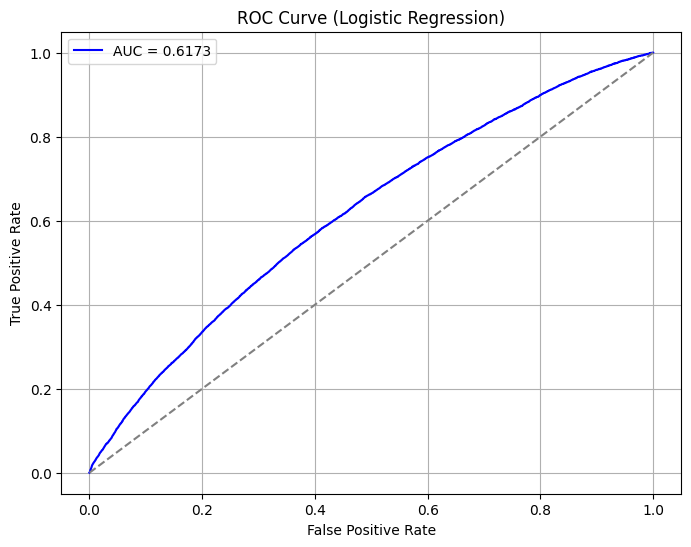

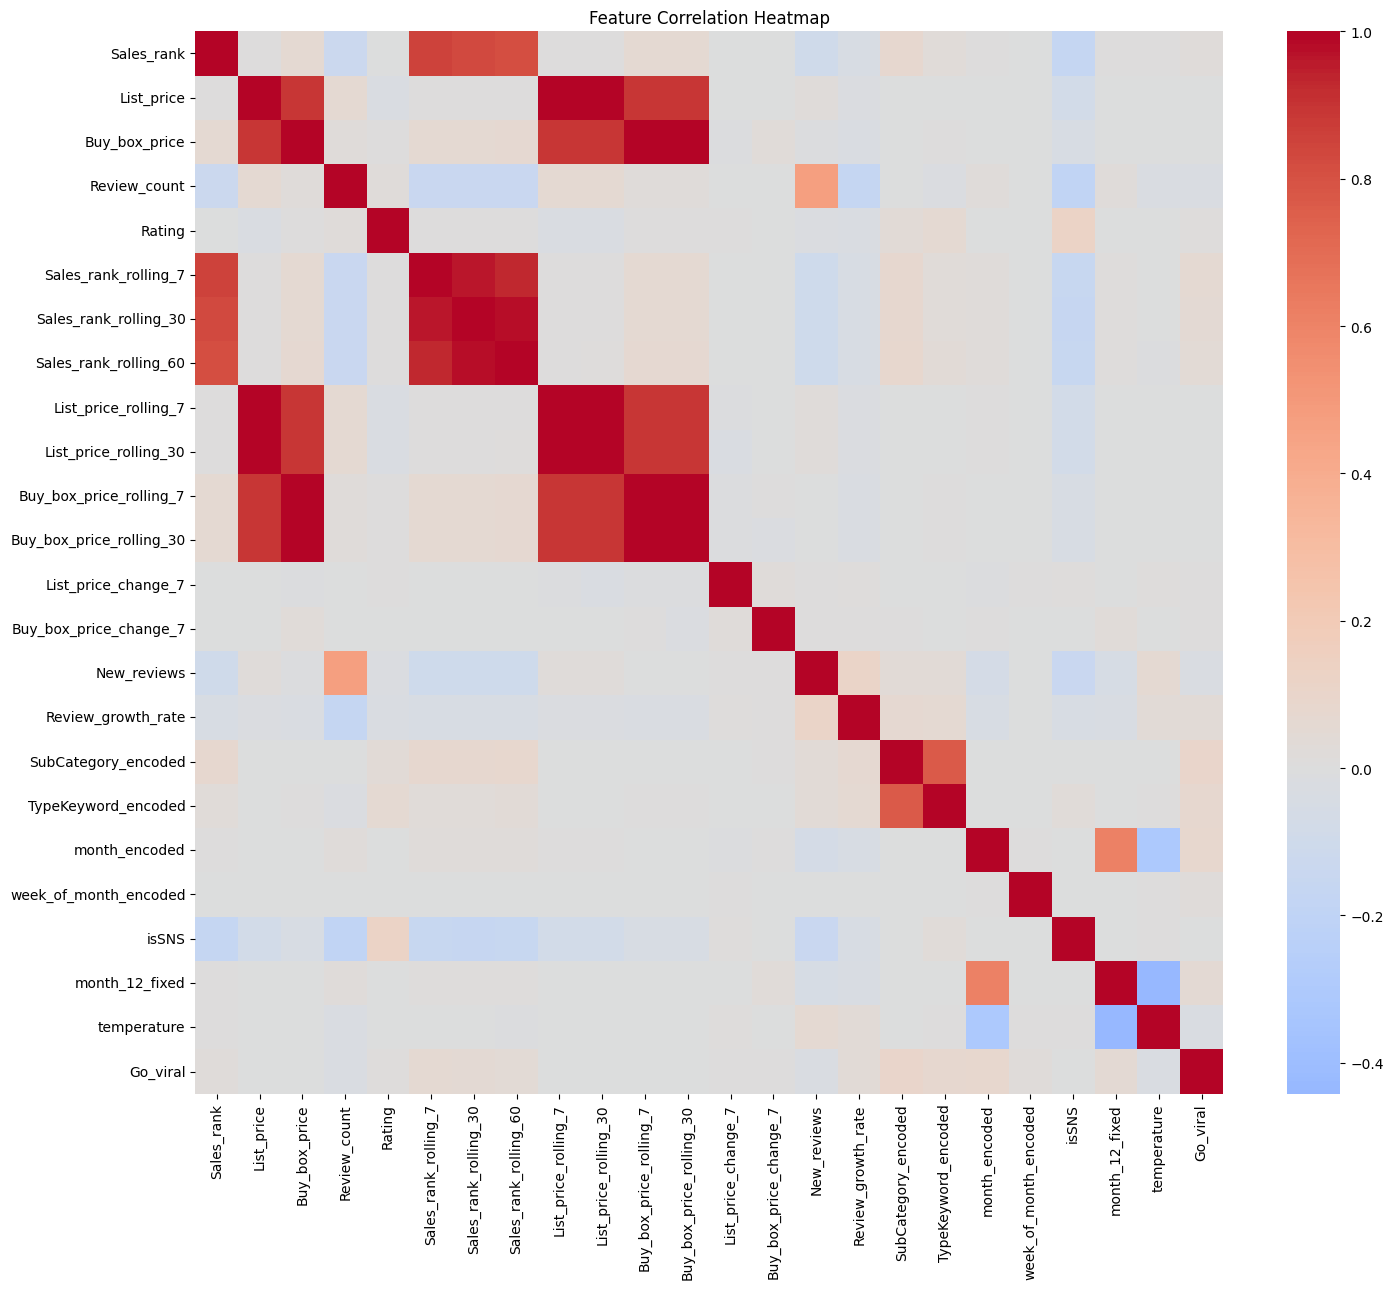

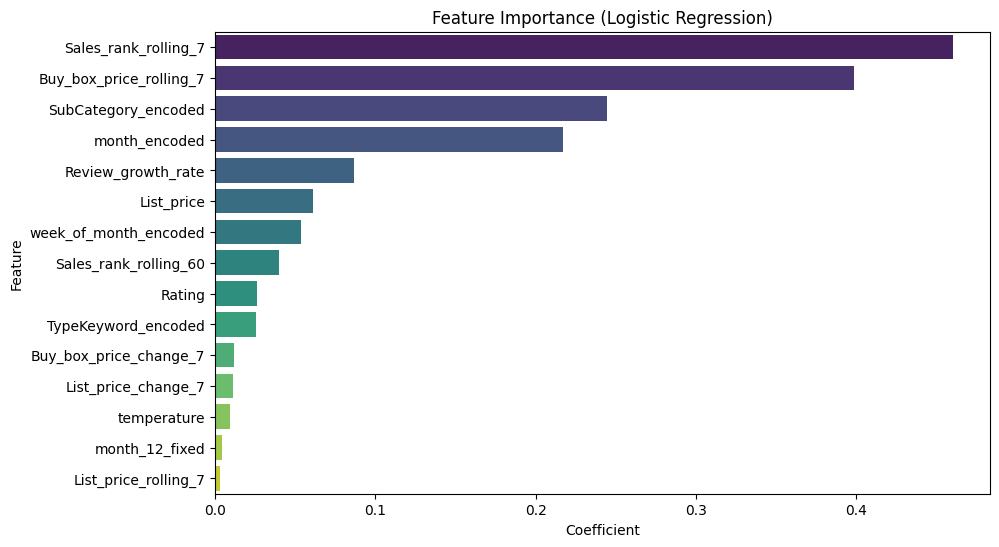


✅ Logistic Regression Model & Correlation Analysis Completed!


In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# 🎯 1️⃣ データ準備
global features
X = df_updated_scaled[features]
y = df_updated_scaled["Go_viral"]

# 🎯 2️⃣ 学習データとテストデータに分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 🎯 3️⃣ クロスバリデーション設定
cv_folds = 5
cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

# 🎯 4️⃣ Logistic Regression の クロスバリデーション
lr_model = LogisticRegressionCV(
    cv=cv, 
    penalty="l2",  # L2正則化
    scoring="roc_auc", 
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)
lr_model.fit(X_train, y_train)

# 🎯 5️⃣ 最適な C を使って Logistic Regression を学習
best_C = lr_model.C_[0]
final_lr_model = LogisticRegression(
    C=best_C, 
    penalty="l2", 
    max_iter=1000, 
    random_state=42,
    class_weight="balanced"
)
final_lr_model.fit(X_train, y_train)

# 🎯 6️⃣ 予測と評価
y_pred_proba = final_lr_model.predict_proba(X_test)[:, 1]  # クラス1の確率
y_pred = (y_pred_proba > 0.6).astype(int)  # 閾値 0.5 で分類

# 評価指標の計算
lr_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "AUC": roc_auc_score(y_test, y_pred_proba)
}

# 結果表示
print("\n🎯 Logistic Regression Model Performance (with Cross Validation):")
for metric, value in lr_metrics.items():
    print(f"{metric}: {value:.4f}")

# 🎯 7️⃣ AUC曲線をプロット
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {lr_metrics['AUC']:.4f}", color="blue")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Logistic Regression)")
plt.legend()
plt.grid()
plt.savefig("lr_auc_curve.png")  # AUCプロットを保存
plt.show()

# 🎯 8️⃣ Correlation Heatmap 作成
#correlation_matrix = df_updated_scaled[features].corr()
correlation_matrix = df_updated_scaled[features + ['Go_viral']].corr()
plt.figure(figsize=(15, 13))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")  # ヒートマップを保存
plt.show()

# 🎯 9️⃣ Logistic Regression の 重要度分析
feature_importance = pd.DataFrame(
    {"Feature": features, "Coefficient": final_lr_model.coef_[0]}
).sort_values(by="Coefficient", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="Coefficient", y="Feature", data=feature_importance[:15], palette="viridis")
plt.title("Feature Importance (Logistic Regression)")
plt.savefig("lr_feature_importance.png")  # 重要度グラフを保存
plt.show()

print("\n✅ Logistic Regression Model & Correlation Analysis Completed!")


# Analysis 2: Random Forest
- CV=5


🚀 Starting Random Forest analysis...

✅ Random Forest Metrics:
accuracy: 0.8302
precision: 0.4921
recall: 0.4065
f1: 0.4452
AUC: 0.7863

📊 Feature importance plot saved to rf_feature_importance_20250319_013027.png

📈 AUC-ROC curve saved to rf_auc_roc_curve_20250319_013027.png

📁 Analysis results saved to rf_analysis_results_20250319_013027.csv


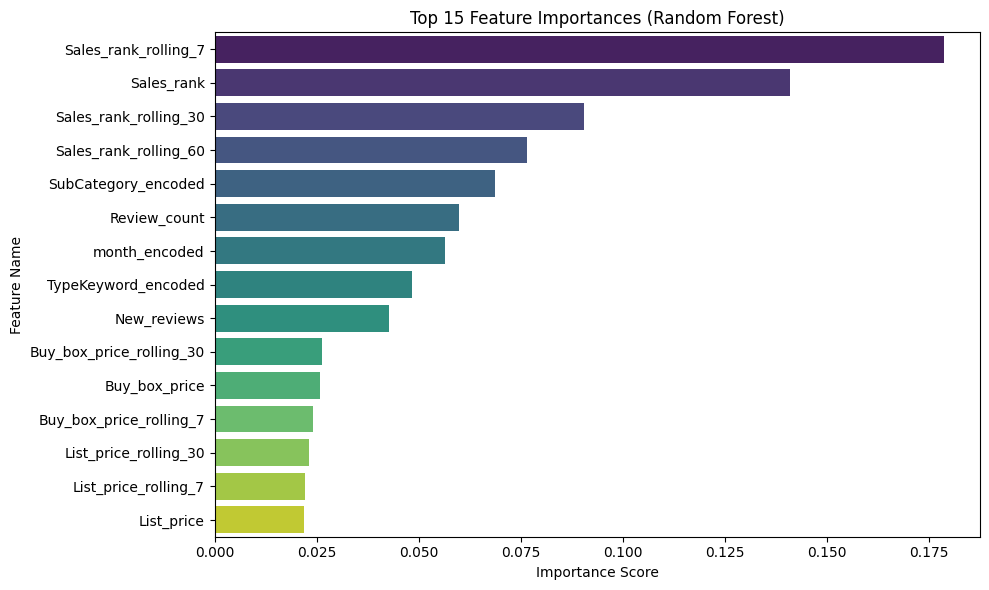

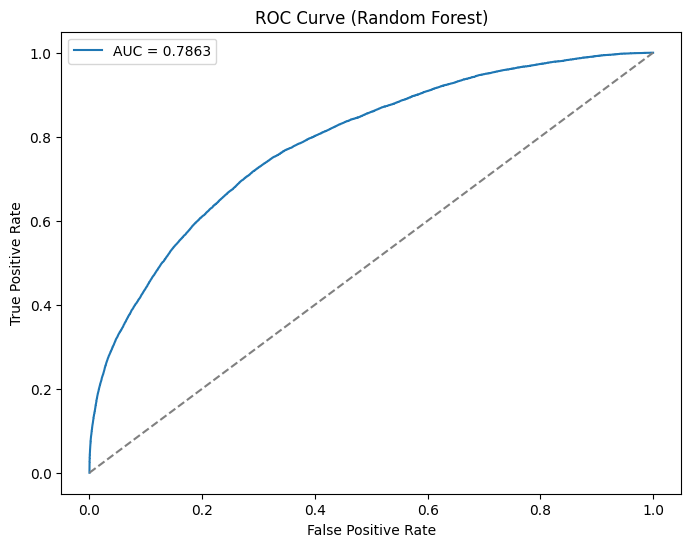

In [68]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
# import seaborn as sns


def analyze_with_random_forest():
    """Analyze global final_df using Random Forest and save results"""
    global df_updated_scaled, rf_metrics  # グローバル変数を使用

    if df_updated_scaled is None:
        print("⚠️ No valid data for analysis. Please run `process_final_df()` first.")
        return

    print("\n🚀 Starting Random Forest analysis...")

    # 🎯 特徴量 & 目的変数
    #features = [col for col in final_df.columns if col != "Go_viral"]  # "Go_viral" を除く
    global features
    X = df_updated_scaled[features]
    y = df_updated_scaled["Go_viral"]

    # 🎯 訓練データ & テストデータ分割 (80%:20%)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, stratify=y, random_state=42
    )

    # 🎯 クロスバリデーション (5-fold)
    cv_folds = 5
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

    # 🎯 Random Forest モデル定義
    rf_model = RandomForestClassifier(
        n_estimators=100,  # 決定木の数
        max_depth=10,  # 最大深さ
        class_weight="balanced",  # クラス不均衡に対応
        random_state=42,
        n_jobs=-1  # 並列処理を有効化
    )

    # 🎯 クロスバリデーションで評価
    cv_auc = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring="roc_auc")

    # 🎯 モデルの学習
    rf_model.fit(X_train, y_train)

    # 🎯 予測
    #y_pred = rf_model.predict(X_test)
    y_pred_proba = rf_model.predict_proba(X_test)[:, 1]  # クラス1 (Go_viral=1) の確率
    y_pred = (y_pred_proba >= 0.6).astype(int)


    # 🎯 評価指標計算
    rf_metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_pred_proba),
        #"CV_AUC_mean": np.mean(cv_auc)  # クロスバリデーションの平均AUC
    }

    print("\n✅ Random Forest Metrics:")
    for metric, value in rf_metrics.items():
        print(f"{metric}: {value:.4f}")

    # 🎯 特徴量の重要度プロット
    # `X_train.columns` を使って features を取得
    features = list(X_train.columns)
    feature_importance = pd.DataFrame(
        {"Feature": features, "Importance": rf_model.feature_importances_}
    ).sort_values(by="Importance", ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x="Importance", y="Feature", data=feature_importance[:15], palette="viridis")
    plt.title("Top 15 Feature Importances (Random Forest)")
    plt.xlabel("Importance Score")
    plt.ylabel("Feature Name")
    plt.tight_layout()

    # 🎯 保存
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    feature_imp_path = f"rf_feature_importance_{timestamp}.png"
    plt.savefig(feature_imp_path)
    print(f"\n📊 Feature importance plot saved to {feature_imp_path}")

    # 🎯 AUC-ROC 曲線を描画
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"AUC = {rf_metrics['AUC']:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # ランダム予測の基準線
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (Random Forest)")
    plt.legend()

    # 🎯 保存
    roc_path = f"rf_auc_roc_curve_{timestamp}.png"
    plt.savefig(roc_path)
    print(f"\n📈 AUC-ROC curve saved to {roc_path}")

    # 🎯 評価結果を保存
    results_path = f"rf_analysis_results_{timestamp}.csv"
    pd.DataFrame([rf_metrics]).to_csv(results_path, index=False)
    print(f"\n📁 Analysis results saved to {results_path}")

    return rf_metrics, rf_model


if __name__ == "__main__":
    analyze_with_random_forest()


# Analysis 3: XGBoost: Cross-Validation (5-fold)
- CV = 5


🎯 XGBoost Model Performance (with Cross Validation):
accuracy: 0.8483
precision: 0.5407
recall: 0.6289
f1: 0.5814
AUC: 0.8658


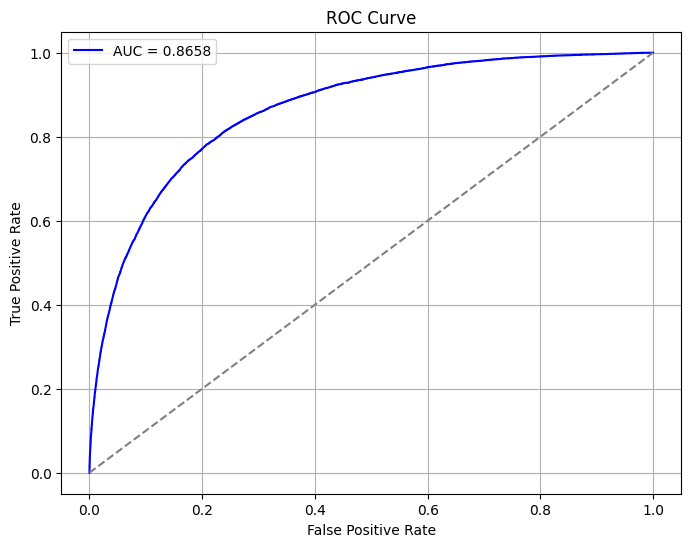

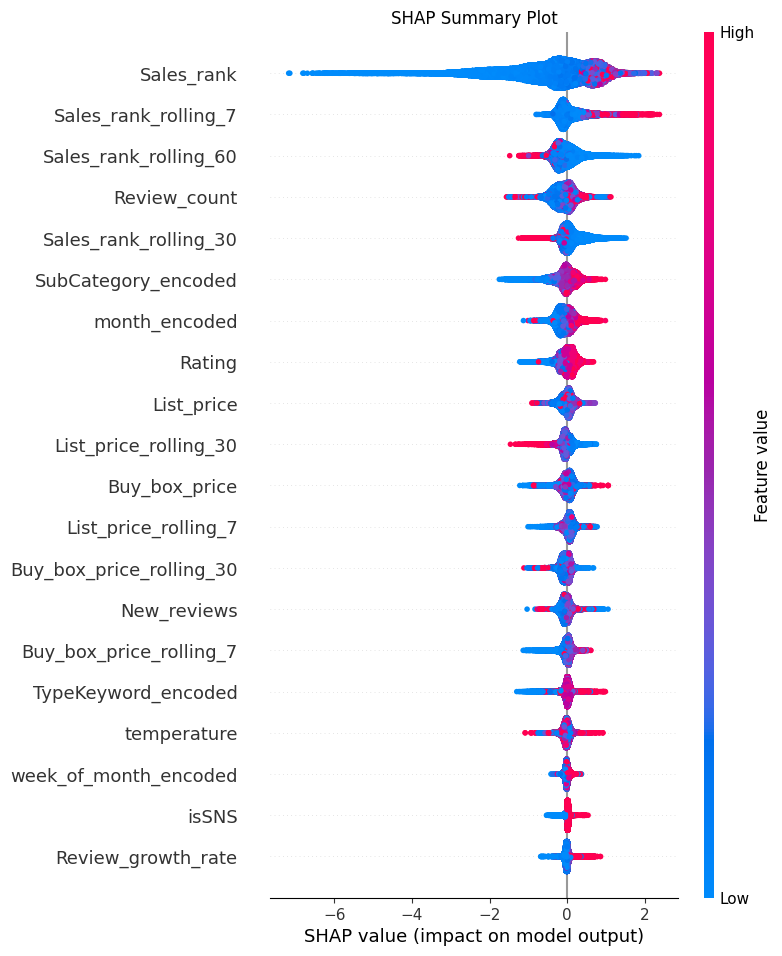

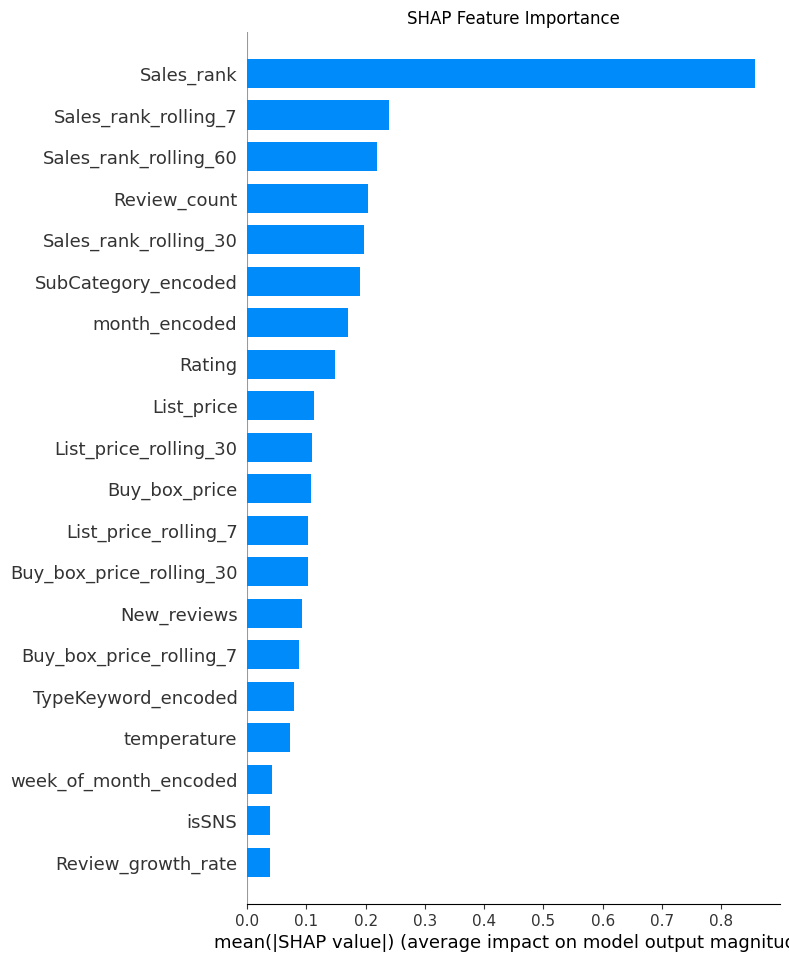


✅ XGBoost Model (with Cross Validation) & SHAP Analysis Completed!


In [ ]:
# import shap
# import xgboost as xgb
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from sklearn.model_selection import train_test_split, StratifiedKFold
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# 🎯 1️⃣ データ準備
global features
X = df_updated_scaled[features]
y = df_updated_scaled["Go_viral"]

# 🎯 2️⃣ 学習データとテストデータに分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 🎯 3️⃣ クロスバリデーション設定
cv_folds = 5
cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

# XGBoost パラメータ設定
xgb_params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "random_state": 42,
    "scale_pos_weight": len(y_train[y_train == 0]) / max(1, len(y_train[y_train == 1]))  # クラス不均衡対応
}

# 🎯 4️⃣ クロスバリデーション実施
cv_results = xgb.cv(
    params=xgb_params,
    dtrain=xgb.DMatrix(X_train, label=y_train),
    num_boost_round=100,  # 最大100回のブースティング
    folds=cv,
    early_stopping_rounds=10,  # 10回連続で改善しなければストップ
    metrics=["logloss", "auc"],  # ログ損失とAUCを記録
    as_pandas=True,
    seed=42
)

# 🎯 5️⃣ ベストなブーストラウンドを取得して再学習
best_num_boost_round = len(cv_results)
xgb_cv5_model = xgb.train(
    params=xgb_params,
    dtrain=xgb.DMatrix(X_train, label=y_train),
    num_boost_round=best_num_boost_round
)

# 🎯 6️⃣ 予測と評価
y_pred_proba = xgb_cv5_model.predict(xgb.DMatrix(X_test))  # 確率値
y_pred = (y_pred_proba > 0.6).astype(int)  # 閾値 0.5 で分類

# 評価指標の計算
xgb_cv5_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "AUC": roc_auc_score(y_test, y_pred_proba)
}

# 結果表示
print("\n🎯 XGBoost Model Performance (with Cross Validation):")
for metric, value in xgb_cv5_metrics.items():
    print(f"{metric}: {value:.4f}")

# 🎯 7️⃣ AUC曲線をプロット
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {xgb_cv5_metrics['AUC']:.4f}", color="blue")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.savefig("xgb_auc_curve.png")  # AUCプロットを保存
plt.show()

# 🎯 8️⃣ SHAP解析
explainer = shap.TreeExplainer(xgb_cv5_model)
shap_values = explainer.shap_values(X_test)

# 🎯 SHAP Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=X.columns, show=False)
plt.title("SHAP Summary Plot")
plt.savefig("shap_summary_plot.png", bbox_inches="tight")  # 画像保存
plt.show()

# 🎯 SHAP Bar Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=X.columns, plot_type="bar", show=False)
plt.title("SHAP Feature Importance")
plt.savefig("shap_bar_plot.png", bbox_inches="tight")  # 画像保存
plt.show()

print("\n✅ XGBoost Model (with Cross Validation) & SHAP Analysis Completed!")


# Analysis 6: XGBoost: Cross-Validation & Grid Search
- CV = 5 w/ Grid Search

Fitting 5 folds for each of 108 candidates, totalling 540 fits

✅ Best Parameters Found by GridSearchCV:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 150, 'subsample': 0.8}

🎯 XGBoost Model Performance (Optimized with GridSearchCV):
accuracy: 0.8566
precision: 0.8642
recall: 0.1710
f1: 0.2855
AUC: 0.8642


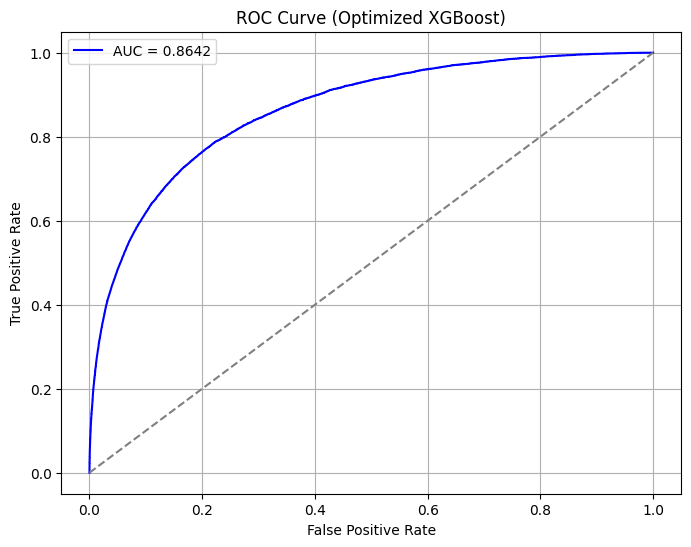

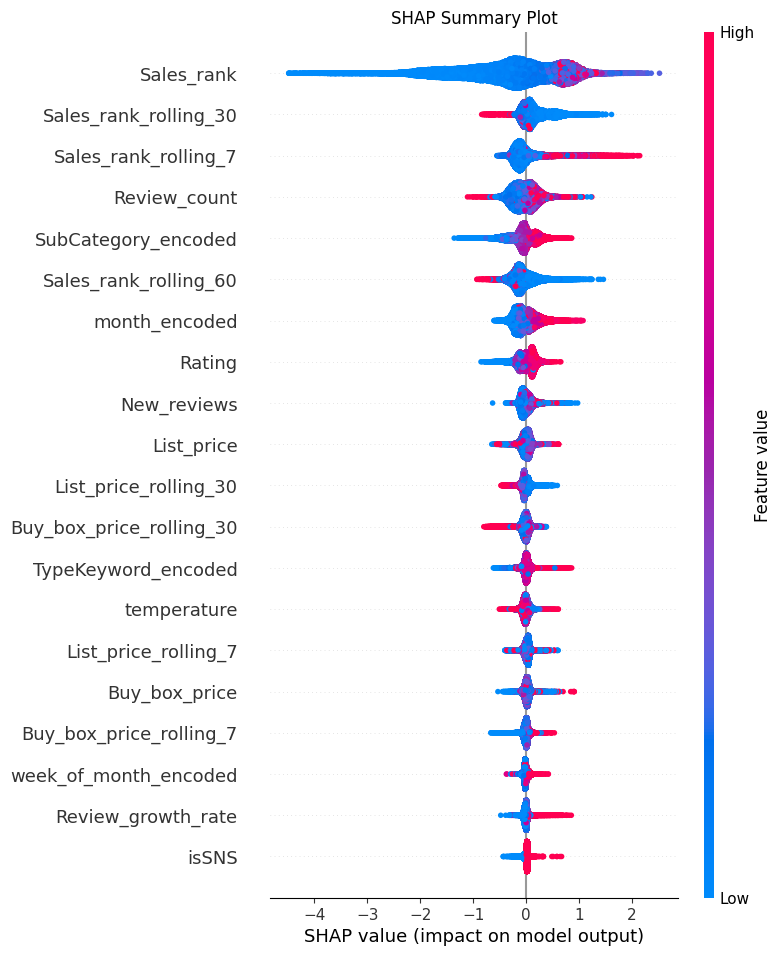

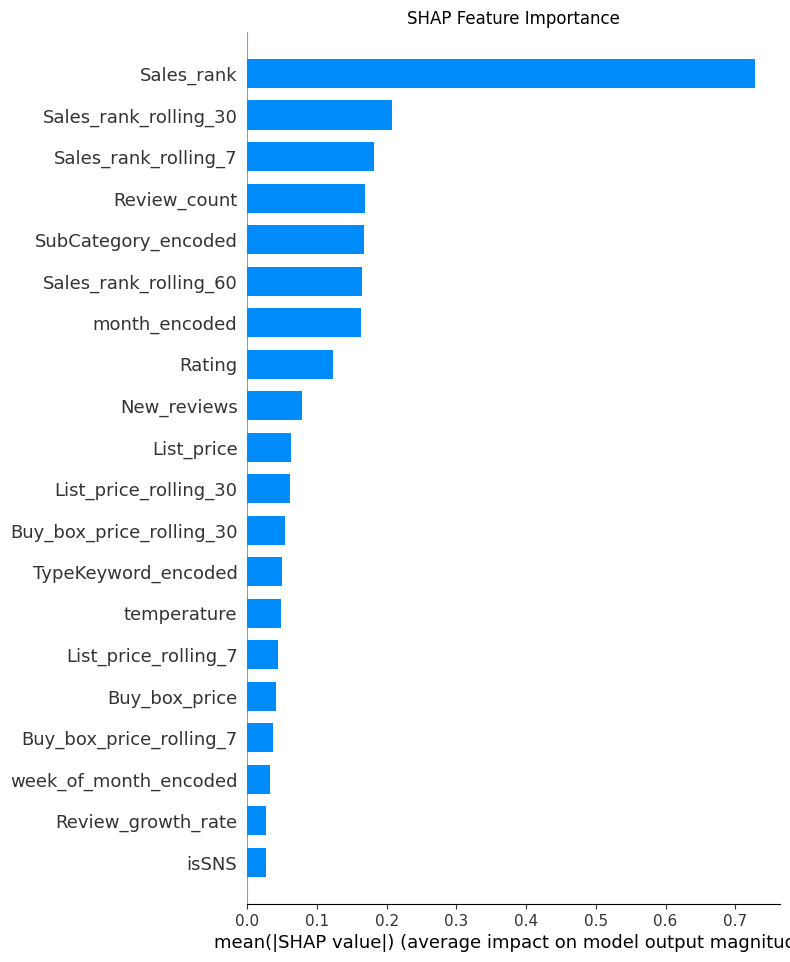


✅ Optimized XGBoost Model (with GridSearchCV) & SHAP Analysis Completed!


In [12]:
# import shap
# import xgboost as xgb
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# 🎯 1️⃣ データ準備
global features
X = df_updated_scaled[features]
y = df_updated_scaled["Go_viral"]

# 🎯 2️⃣ 学習データとテストデータに分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 🎯 3️⃣ クロスバリデーション設定
cv_folds = 5
cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

# 🎯 4️⃣ グリッドサーチ用パラメータ
param_grid = {
    "max_depth": [3, 5, 7],               # 決定木の深さ
    "learning_rate": [0.01, 0.05, 0.1],   # 学習率
    "n_estimators": [50, 100, 150],       # 木の数
    "subsample": [0.8, 1.0],              # サブサンプル率
    "colsample_bytree": [0.8, 1.0]        # 特徴量のサブサンプル率
}

# 🎯 5️⃣ XGBoostモデル & グリッドサーチ
xgb_clf = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=len(y_train[y_train == 0]) / max(1, len(y_train[y_train == 1]))  # クラス不均衡対応
)

grid_search = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    verbose=1,
    n_jobs=-1
)

# 🎯 6️⃣ グリッドサーチの実行
grid_search.fit(X_train, y_train)

# 🎯 7️⃣ 最適パラメータの取得
best_params = grid_search.best_params_
print("\n✅ Best Parameters Found by GridSearchCV:")
print(best_params)

# 🎯 8️⃣ 最適パラメータで XGBoost を再学習
best_xgb_model = xgb.XGBClassifier(**best_params, eval_metric="logloss", random_state=42)
best_xgb_model.fit(X_train, y_train)

# 🎯 9️⃣ 予測と評価
y_pred_proba = best_xgb_model.predict_proba(X_test)[:, 1]  # クラス1の確率
y_pred = (y_pred_proba > 0.6).astype(int)  # Setting Threshold

# 評価指標の計算
xgb_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "AUC": roc_auc_score(y_test, y_pred_proba)
}

# 結果表示
print("\n🎯 XGBoost Model Performance (Optimized with GridSearchCV):")
for metric, value in xgb_metrics.items():
    print(f"{metric}: {value:.4f}")

# 🎯 1️⃣0️⃣ AUC曲線をプロット
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {xgb_metrics['AUC']:.4f}", color="blue")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Optimized XGBoost)")
plt.legend()
plt.grid()
plt.savefig("optimized_xgb_auc_curve.png")  # AUCプロットを保存
plt.show()

# 🎯 1️⃣1️⃣ SHAP解析
explainer = shap.TreeExplainer(best_xgb_model)
shap_values = explainer.shap_values(X_test)

# 🎯 SHAP Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=X.columns, show=False)
plt.title("SHAP Summary Plot")
plt.savefig("optimized_shap_summary_plot.png", bbox_inches="tight")  # 画像保存
plt.show()

# 🎯 SHAP Bar Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=X.columns, plot_type="bar", show=False)
plt.title("SHAP Feature Importance")
plt.savefig("optimized_shap_bar_plot.png", bbox_inches="tight")  # 画像保存
plt.show()

print("\n✅ Optimized XGBoost Model (with GridSearchCV) & SHAP Analysis Completed!")


# Results matrix

In [69]:
# すべての評価指標をDataFrameに変換
evaluation_df = pd.DataFrame({
    "Logistic Regression": lr_metrics,
    "Random Forest": rf_metrics,
    "XGBoost(CV=5)": xgb_cv5_metrics,
    "XGBoost(CV=5 & GridSearch)": xgb_metrics
}).T

# 欠損値を埋める
evaluation_df = evaluation_df.fillna("-")

print(evaluation_df)

                            accuracy  precision    recall        f1       AUC
Logistic Regression         0.785931   0.283266  0.181371  0.221146  0.617294
Random Forest               0.830249   0.492092  0.406539  0.445243  0.786290
XGBoost(CV=5)               0.848288   0.540664  0.628871  0.581441  0.865836
XGBoost(CV=5 & GridSearch)  0.856593   0.864245  0.171029  0.285549  0.864198


# Distribution of Sales rank Before & After of detected products

In [15]:
# 🎯 1️⃣ スケーリングを元に戻す
df_original_values = df_updated.copy()  # 元データのコピー

# `features` のスケーリングを戻す
#df_original_values[features] = scaler.inverse_transform(df_updated_scaled[features])

# 🎯 2️⃣ Viralと予測されたレコードの元のSales Rankと予測後のSales Rankを取得
viral_indices = X_test[y_pred == 1].index  # 予測でViralとされたレコードのインデックス

# 元のスケールに戻したデータを参照
df_viral_sales = df_original_values.loc[viral_indices, ["ASIN", "Sales_rank", "Sales_rank_change_30d"]].copy()

# 🎯 3️⃣ 未来のSales Rankを計算
df_viral_sales["Future_Sales_Rank"] = df_viral_sales["Sales_rank"] * (1 + df_viral_sales["Sales_rank_change_30d"] / 100)

# 🎯 4️⃣ 確認
print("\n✅ 元のスケールに戻した Sales Rank:")
print(df_viral_sales.head(500))



✅ 元のスケールに戻した Sales Rank:
              ASIN  Sales_rank  Sales_rank_change_30d  Future_Sales_Rank
242409  B07MWYH7SW    2060.000             -83.446602         341.000000
149046  B01H3OA816     760.000             -48.421053         392.000000
364968  B01CDZARFW   71358.000             -99.115726         631.000000
260791  B0BCX7SQG6    2030.000             -81.131619         383.028143
173141  B000QFT1RC      47.000             -17.021277          39.000000
...            ...         ...                    ...                ...
312311  B09VZNSTRL     979.375              -4.478335         935.515303
145360  B07SP2XD76    1346.000             -89.975872         134.924764
421503  B06XZXFKF7    1598.000              -3.191489        1547.000000
281940  B09VXN6CM3    2016.625             -70.275007         599.441645
428486  B0C42M839N      32.000             -71.875000           9.000000

[500 rows x 4 columns]


# Density distribution of sales rank Before & After
- Products detected as Go_Viral

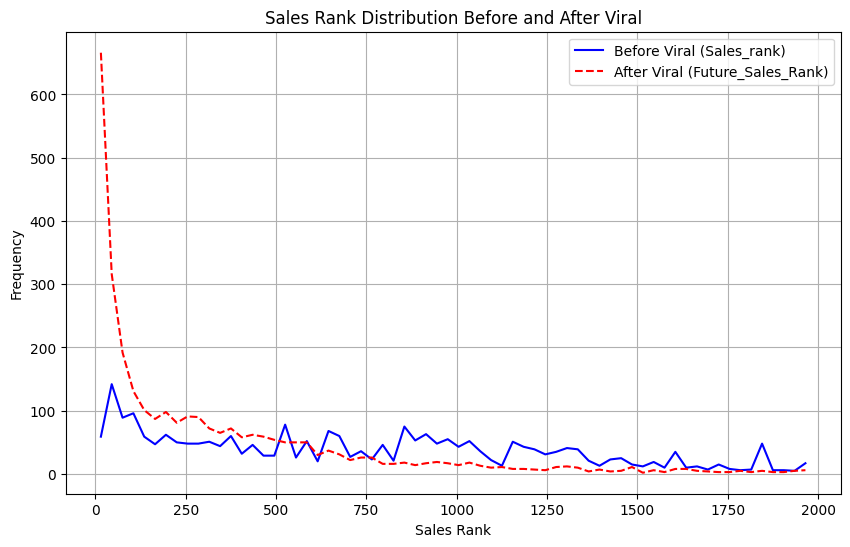

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# 30区切りのbinを作成
bins = np.arange(0, 2000, 30)

# 各binで度数をカウント
sales_rank_hist, _ = np.histogram(df_viral_sales["Sales_rank"], bins=bins)
future_sales_rank_hist, _ = np.histogram(df_viral_sales["Future_Sales_Rank"], bins=bins)

# プロット用のx軸 (各binの中心を使用)
bin_centers = (bins[:-1] + bins[1:]) / 2

# グラフの作成
plt.figure(figsize=(10, 6))
plt.plot(bin_centers, sales_rank_hist, label="Before Viral (Sales_rank)", color="blue", linestyle="-")
plt.plot(bin_centers, future_sales_rank_hist, label="After Viral (Future_Sales_Rank)", color="red", linestyle="--")

# ラベルとタイトル
plt.xlabel("Sales Rank")
plt.ylabel("Frequency")
plt.title("Sales Rank Distribution Before and After Viral")
plt.legend()
plt.grid(True)

# グラフを表示
plt.show()


# Wkly sales units calculation by using formula from the study

In [40]:
import numpy as np
import pandas as pd

# 数式を適用する関数
def calculate_weekly_sales(rank):
    #return np.exp((10.72 - np.log(rank - 1)) / -0.516)
    return np.exp((np.log(rank - 1) - 10.72) / -0.516)

# Sales Rank の Before, After が 400 - 3000 の範囲のデータを抽出
df_filtered = df_viral_sales[(df_viral_sales['Sales_rank'].between(400, 3000)) &
                             (df_viral_sales['Future_Sales_Rank'].between(400, 3000))].copy()

# 数式を適用して Weekly Sales を計算
df_filtered['Weekly_Sales_Before'] = calculate_weekly_sales(df_filtered['Sales_rank'])
df_filtered['Weekly_Sales_After'] = calculate_weekly_sales(df_filtered['Future_Sales_Rank'])
df_filtered['Expected_increase'] = df_filtered['Weekly_Sales_After'] - df_filtered['Weekly_Sales_Before']

# 必要なカラムのみを保持
df_result = df_filtered[['ASIN', 'Sales_rank', 'Future_Sales_Rank', 'Weekly_Sales_Before', 'Weekly_Sales_After','Expected_increase']]

# 🎯 Expected_increase の平均を計算
expected_increase_mean = df_result['Expected_increase'].mean()

# 🎯 Expected_increase の正負カウント
tp_count = (df_result['Expected_increase'] > 0).sum()  # True Positive (売上が増えた)
fp_count = (df_result['Expected_increase'] < 0).sum()  # False Positive (売上が減った)

# 結果表示
print(df_result.head(5))
print("\n=== Analysis Summary ===\n-Mid-rank Products (rank:400-3000)")
print(f"-Records: 766, Unique ASIN: {len(df_result['ASIN'].unique())}")
print(f"Expected Increase units (mean): {expected_increase_mean:.2f}")
print(f"True Positive (Sales increased): {tp_count}")
print(f"False Positive (Sales decreased): {fp_count}")


              ASIN  Sales_rank  Future_Sales_Rank  Weekly_Sales_Before  \
32574   B000261MX6      1178.0        1617.000000          1178.785679   
345205  B07D1HRQNK      1695.0         400.000000           582.060204   
286550  B00DT2WL26      1794.0         569.000000           521.391407   
301839  B00OP6SVJW      2629.0         970.411383           248.525580   
42612   B08DTNC3VY      2559.0         703.379409           261.874744   

        Weekly_Sales_After  Expected_increase  
32574           637.738185        -541.047494  
345205         9591.949430        9009.889227  
286550         4838.019958        4316.628551  
301839         1716.902379        1468.376799  
42612          3205.826890        2943.952146  

=== Analysis Summary ===
-Mid-rank Products (rank:400-3000)
-Records: 766, Unique ASIN: 205
Expected Increase units (mean): 2471.12
True Positive (Sales increased): 651
False Positive (Sales decreased): 115
